# Natural Language Processing (NLP) / Generative AI R&D
## Phone Exception Survey 
### Data Processing (Generative Query)

Read inputs from a series of PDFs and perform:

+ Data Save to a unified format
+ Sentiment Analysis and Sentiment Confidence
+ Categorization
+ All comments Word Cloud
+ All comments Summarization

Output presented to Power BI dashboard.

### Version History
+ v0.1 - Initial prototype, minimal to no data cleansing, inside source and reviewed by HITL.
+ v0.2 - Added code to read all PDF's, process generative results, use a data class, use PDF Miner to parse the form.  Pending join of data from PDF's into Panda's Data Frame.
+ v0.3 - Found multiple "forms" in the data payload, a resultant of "Unknown" in user name and user email means the "form" is not the standard "WO form" and is therefore invalid.  Created new DF output.
+ v0.4 - Fixed problem with CIO, SUpervisor and Boss fields not loading in datastructure.


### TODO
+ None

### Privacy Information

No action taken.

### Prompt Injection Defense

No action taken.

### References:
+  https://pdfminersix.readthedocs.io/en/latest/howto/acro_forms.html

### Technical References

### Jupyte Notebook Hints
+  https://jupyter-tutorial.readthedocs.io/en/24.1.0/notebook/shortcuts.html

In [1]:
# -*- coding: utf-8 -*-

### Environment Validation

Using GCP or Azure read in arrays representing minimal library requirements (which might not be present in a Google Colab environment) and install / load the libraries as required.  Additional imports for standard libraries and tailored content to follow.

In [2]:
#specific libraries like cudf and GPU enabled libs will not load via typical pip install efforts.
#use anaconda to install those capabilities into you env within the kernel you're using
#For CUDF within the desired Anaconda environment:
#    conda install -c rapidsai -c conda-forge -c nvidia rapids=24.06 

###########################################
#- Minimal imports to start
###########################################
try:
    import sys
    import subprocess
    import importlib.util
    import atexit
except ImportError as e:
    print("There was a problem importing the most basic libraries necessary for this code.")
    print(repr(e))
    raise SystemExit("Stop right there!")

###########################################
#- Final Exit Routine
###########################################
@atexit.register
def goodbye():
    print("GOODBYE")

###########################################
#- Cloud Environment Setup (Priming)
###########################################
# variables establishing environments
ENV_GCP=0
ENV_AZURE=1
user_input=-1
environments=["GCP", "Azure"]
    
#prompt user for environment before continuing
user_input = 0
while True:
  try:
     if user_input > -1:
         break;
     user_input = int(input("Select the environment you're running: (0) GCP (1) Azure"))     
     if user_input > 1:
         print("Not a valid choice, please try again.")
         continue;
  except ValueError:
     print("Not a valid choice, please try again.")
     continue
  else:
     print(f"Environment selected is: {environments[user_input]}")
     break 
        
############################################
#- Import a custom library, in this case a fairly useful logging framework
############################################
from pathlib import Path
debug_lib_location = Path("../ML-Support")
sys.path.append(str(debug_lib_location))
try:
  import debug
  debug.msg_debug("...debug library loaded.")
except ImportError as e:
  print("There was a problem importing the debug library.")
  print(repr(e))
  raise SystemExit("Without the debug logging library, this code will not run.")

libraries=["transformers", "langchain", "openpyxl", "python-dotenv", "gensim", 
           "alive-progress", "tqdm", "pyspellchecker", "wordcloud", "langchain", "icecream", "numba", 
           "fitz","dataclasses", "commonregex", "transformers", "spacy", "PyMuPDF", "PyPDF2", "pdfminer", 
           "pdfplumber","pdf2image","pytesseract", "cupy" ]    
debug.msg_info(f"Validating environment for the following pip packages: {libraries}")

#load environment for non-generative libraries
try:
    for library in libraries:
      if library == "Pillow":
        spec = importlib.util.find_spec("PIL")
      else:
        spec = importlib.util.find_spec(library)
      if spec is None:
        print("...installing library " + library)
        subprocess.run(["pip", "install" , library, "--quiet"])
      else:
        print("...library " + library + " already installed.")
except (subprocess.CalledProcessError, Exception) as e:
    print("Error: Failed to install required packages, your code might not run properly.")
    print(repr(e))

#load environment specific libraries for generative AI.
try:    
    if environments[user_input]=="GCP":
      subprocess.run(["pip", "install" , "--upgrade", "google-cloud-aiplatform", "--quiet"])
      subprocess.run(["pip", "install" , "--upgrade", "google-cloud-secret-manager", "--quiet"])
      gcp_libraries=["google-generativeai","google.protobuf", "google.generativeai", "google.cloud.aiplatform_v1beta1",]
      for library in gcp_libraries:
        spec = importlib.util.find_spec(library)
        if spec is None:
          print("...installing library " + library)
          try:
              subprocess.run(["pip", "install" , library, "--quiet"])
          except (subprocess.CalledProcessError, Exception) as e:
              print("Error: Failed to install required packages, your code might not run properly.")
              print(repr(e))
        else:
          print("...library " + library + " already installed.")
    
        from google.cloud import aiplatform
        import vertexai.preview
        import vertexai
        import openai
        from google.auth import default, transport
        from google.cloud import secretmanager
        import google.generativeai as genai
        from vertexai.preview.generative_models import GenerativeModel
        from vertexai.preview.generative_models import GenerationConfig
        from google.cloud.aiplatform_v1beta1.types.openapi import Schema
        from google.cloud.aiplatform_v1beta1.types.openapi import Type
        from google.protobuf.json_format import MessageToDict        
        
          
    elif environments[user_input]=="Azure":
      azure_libraries=["openai", ]
      for library in azure_libraries:
        spec = importlib.util.find_spec(library)
        if spec is None:
          print("...installing library " + library)
          print("...installing library " + library)
          try:
              subprocess.run(["pip", "install" , library, "--quiet"])
          except (subprocess.CalledProcessError, Exception) as e:
              print("Error: Failed to install required packages, your code might not run properly.")
              print(repr(e))
        else:
          print("...library " + library + " already installed.")
    else:
        print("There was a problem processing your request.  Only numeric input of 0 or 1 is allowed.")
        print("Continued operations is not possible without the proper installed tools.")
        raise SystemExit("Stop right there!")
except Exception as e:
    print("There was a problem processing library installs for Generative AI libraries")
    print(repr(e))
    raise SystemExit("Stop right there!")

debug.msg_debug("...dynamic environment installs complete.")

[2024-11-19 14:55:02 UTC]   DEBUG: ...debug library loaded. 
[2024-11-19 14:55:02 UTC]    INFO: Validating environment for the following pip packages: ['transformers', 'langchain', 'openpyxl', 'python-dotenv', 'gensim', 'alive-progress', 'tqdm', 'pyspellchecker', 'wordcloud', 'langchain', 'icecream', 'numba', 'fitz', 'dataclasses', 'commonregex', 'transformers', 'spacy', 'PyMuPDF', 'PyPDF2', 'pdfminer', 'pdfplumber', 'pdf2image', 'pytesseract', 'cupy'] 
...library transformers already installed.
...library langchain already installed.
...library openpyxl already installed.
...installing library python-dotenv
...library gensim already installed.
...installing library alive-progress
...library tqdm already installed.
...installing library pyspellchecker
...library wordcloud already installed.
...library langchain already installed.
...library icecream already installed.
...library numba already installed.
...library fitz already installed.
...library dataclasses already installed.
...lib

### Additional Libraries

Read in core libraries, local logging framework, data science tools, Natural Language Processing Toolkit (NLTK), Spacy and other tools to support the effort.

In [3]:
debug.msg_info("Library imports")    
############################################
# INCLUDES
############################################

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# a set of libraries that perhaps should always be in Python source
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...core libraries.")
import os
import datetime
from dateutil import parser
import gc
import socket
import sys
import getopt
import inspect
import traceback
import warnings
import json
import pickle
from pathlib import Path
import itertools
import datetime
import re
import shutil
import string
from io import StringIO
import tqdm


import io
import math
import textwrap
import random
import glob
import time
from time import perf_counter
import subprocess
from multiprocessing import Pool
import backoff                    #annotation to support repeat calls on api failure


from unidecode import unidecode   #to handle strange characters
from dotenv import load_dotenv    #load environment vars/keys/etc...

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Function Profiling
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
import cProfile
import pstats
import io
from pstats import SortKey

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# MS Excel Libraries
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
from openpyxl import Workbook
from openpyxl.utils import get_column_letter
from openpyxl.styles import PatternFill, GradientFill
from openpyxl.styles import Border, Side
from openpyxl.styles import Alignment
from openpyxl.styles import Font

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Data Science Libraries
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...classic data science libraries.")

#optimization routines
from numba import jit
import numpy as np
import scipy as sp
#from sklearn.linear_model import LinearRegression


# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Additional libraries for this work
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...application specific libraries.")
import math
from base64 import b64decode
from IPython.display import Image
import requests
from bs4 import BeautifulSoup                 #used to parse the text
from wordcloud import WordCloud, STOPWORDS    #custom library specifically designed to make word clouds
from spellchecker import SpellChecker

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- PDF Libraries
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
import fitz
from pdfminer.pdfparser import PDFParser
from pdfminer.pdfdocument import PDFDocument
from pdfminer.pdftypes import resolve1
from pdfminer.psparser import PSLiteral, PSKeyword
from pdfminer.utils import decode_text

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Graphics
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...graphics.")
#import PIL
from PIL import Image
import PIL.ImageOps
import matplotlib as matplt
import matplotlib.pyplot as plt

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# progress bar
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...progress bars.")
from alive_progress import alive_bar
#from alive_progress.styles import showtime, Show
from tqdm.notebook import trange, tqdm
#from tqdm import trange, tqdm

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- PII libraries (regular expressions)
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...regular expressions for PII and transformers for prompt injection defense.")
from commonregex import CommonRegex
from commonregex import email
from commonregex import time
from commonregex import credit_card
from commonregex import ip
from commonregex import ipv6
from commonregex import link
from commonregex import phone
from commonregex import street_address
from commonregex import btc_address

debug.msg_debug("...spacy (pii defense).")
import spacy
from spacy.language import Language
from spacy.tokens import Doc

debug.msg_debug("...hugging face model support.")
#injection defense
from transformers import pipeline

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- Tensorflow AI/ML libraries (seek to use GPU's)
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#load first
try:
    debug.msg_debug("...TensorRT")    
    import tensorrt
    assert tensorrt.Builder(tensorrt.Logger())
except ImportError as ie:
    debug.msg_warning("Failed to import tensorrt, this might be a problem if trying for enhanced processing.")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    #load second
    debug.msg_debug("...TensorFlow")        
    import tensorflow as tf
except ImportError as ie:
    debug.msg_warning("Failed to import tensorflow, might not have a GPU or the proper environment loaded")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    debug.msg_debug("...CUDF")    
    import cudf
except ImportError as ie:
    debug.msg_warning("Failed to import cudf, likely don't have a GPU")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    debug.msg_debug("...Torch")    
    import torch
except ImportError as ie:
    debug.msg_warning("Failed to import torch, likely don't have a GPU or access to that library.")
    debug.msg_warning(f"...{repr(ie)}")
    pass

debug.msg_debug("...Pandas")    
import pandas as pd

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- NLTK required resources
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...natural language processing.")
import nltk
from nltk.stem import PorterStemmer  # A word stemmer based on the Porter stemming algorithm.  Porter, M. "An algorithm for suffix stripping." Program 14.3 (1980): 130-137.
from nltk import pos_tag
from nltk.tree import tree
#from nltk.book import *
from nltk import FreqDist
from nltk import sent_tokenize, word_tokenize
from nltk.corpus import stopwords    
from nltk.stem.wordnet import WordNetLemmatizer


nltk.download('punkt')
nltk.download("words")
nltk.download("stopwords")
nltk.download('wordnet')  
nltk.download('omw-1.4')  
#nltk.download('averaged_perceptron_tagger')      #looks like you have to download select neural layers for specific functions, head to read the erorr output to learn this.

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- Topic Modeling
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
from gensim import corpora
from gensim.models import LsiModel
from gensim.models import LdaModel



[2024-11-19 14:55:21 UTC]    INFO: Library imports 
[2024-11-19 14:55:21 UTC]   DEBUG: ...core libraries. 
[2024-11-19 14:55:21 UTC]   DEBUG: ...classic data science libraries. 
[2024-11-19 14:55:21 UTC]   DEBUG: ...application specific libraries. 
[2024-11-19 14:55:21 UTC]   DEBUG: ...graphics. 
[2024-11-19 14:55:21 UTC]   DEBUG: ...progress bars. 
[2024-11-19 14:55:21 UTC]   DEBUG: ...regular expressions for PII and transformers for prompt injection defense. 
[2024-11-19 14:55:21 UTC]   DEBUG: ...spacy (pii defense). 
[2024-11-19 14:55:26 UTC]   DEBUG: ...hugging face model support. 


/opt/conda/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
2024-11-19 14:55:26.919143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-19 14:55:26.943974: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-19 14:55:26.951186: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-19 14:55:26.972601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimiz

[2024-11-19 14:55:32 UTC]   DEBUG: ...TensorRT 


/opt/conda/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


[2024-11-19 14:55:34 UTC]   DEBUG: ...TensorFlow 
[2024-11-19 14:55:34 UTC]   DEBUG: ...CUDF 
[2024-11-19 14:55:34 UTC] WARNING: Failed to import cudf, likely don't have a GPU 
[2024-11-19 14:55:34 UTC] WARNING: ...ModuleNotFoundError("No module named 'cudf'") 
[2024-11-19 14:55:34 UTC]   DEBUG: ...Torch 
[2024-11-19 14:55:34 UTC]   DEBUG: ...Pandas 
[2024-11-19 14:55:34 UTC]   DEBUG: ...natural language processing. 


[nltk_data] Downloading package punkt to /home/jupyter/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package words to /home/jupyter/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jupyter/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jupyter/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jupyter/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Functions

In [4]:
def set_library_configuration() -> None:
    
    ############################################
    #- JUPYTER NOTEBOOK OUTPUT CONTROL / FORMATTING
    ############################################
    #pandas set floating point to 4 places to things don't run loose
    debug.msg_info("Setting Pandas and Numpy library options.")    
    #pd.set_option('display.max_colwidth', 10) # None if you want to view the full json blob in the printed dataframe, use this
    pd.set_option('display.max_colwidth', None) # None if you want to view the full json blob in the printed dataframe, use this
    pd.options.display.float_format = '{:,.4f}'.format
    np.set_printoptions(precision=4)

In [5]:
def profile_function(func):
    def wrapper(*args, **kwargs):
        pr = cProfile.Profile()
        pr.enable()
        result = func(*args, **kwargs)
        pr.disable()
        s = io.StringIO()
        sortby = SortKey.CUMULATIVE
        ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
        ps.print_stats()
        print(s.getvalue())
        return result
    return wrapper

### Configure Tailored Output Configuration

In [6]:
############################################
#- JUPYTER NOTEBOOK OUTPUT CONTROL / FORMATTING
############################################
#pandas set floating point to 4 places to things don't run loose
debug.msg_info("Setting Pandas and Numpy library options.")    
pd.set_option('display.max_colwidth', 10) # None if you want to view the full json blob in the printed dataframe, use this
pd.options.display.float_format = '{:,.4f}'.format
np.set_printoptions(precision=4)

[2024-11-19 14:55:35 UTC]    INFO: Setting Pandas and Numpy library options. 


#### Privacy Information Defense

Look for Spacy entities known as "PERSON" for names of people and using regular expression library to find related PII information and abstract.

#### String Manipulation (Data String Cleanup Routines)

In [7]:
## Read the string and clean up the markdown created by gemini
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @param (Text for type to transform) - str- String type
#  Hat tip to Yvan@google
def markdown_escaper(text: str, type: str = 'json'):
    escape_length = len(f'```{type}')
    if text[:escape_length] == f'```{type}' and text[-3:] == '```':
        return text[escape_length:-3]
    else:
        return text

## Read the markdown provided and turn it into JSON
#
#  @param (Text for text to clean) - str    - Markdown to transform
#  Hat tip to Yvan@google
def markdown_to_json(md: str):
    return json.loads(markdown_escaper(md))

## Read the contents of a text input and anything that doesn't support a potential date format
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
def clean_date(inc_str: str) -> str:
    resumeText = re.sub('httpS+s*', ' ', inc_str)  # remove URLs
    #resumeText = re.sub('RT|cc', ' ', resumeText)  # remove RT and cc
    resumeText = re.sub('#S+', '', resumeText)  # remove hashtags
    resumeText = re.sub('@S+', '  ', resumeText)  # remove mentions
    resumeText = re.sub(r'\r', ' ', resumeText)
    resumeText = re.sub(r'\n', ' ', resumeText)
    resumeText = re.sub(' +', ' ', resumeText) # remove extra whitespace
    resumeText = re.sub(r'\t', ' ', resumeText) #remove tabs

    resumeText.rstrip()
    resumeText.lstrip()
    resumeText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,.:;<=>?@[]^_`{|}~"""), ' ', resumeText)  # remove punctuations

    resumeText=re.sub(r'\W+', ' ', resumeText)
    resumeText=re.sub(' +', ' ', resumeText)       
    return resumeText


## Read the contents of a text input and remove URL's, extra spaces, carriage returns, etc..
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
def clean_text(inc_str: str) -> str:
    resumeText = re.sub('httpS+s*', ' ', inc_str)  # remove URLs
    #resumeText = re.sub('RT|cc', ' ', resumeText)  # remove RT and cc
    resumeText = re.sub('#S+', '', resumeText)  # remove hashtags
    resumeText = re.sub('@S+', '  ', resumeText)  # remove mentions
    resumeText = re.sub(r'\r', ' ', resumeText)
    resumeText = re.sub(r'\n', ' ', resumeText)
    resumeText = re.sub(' +', ' ', resumeText) # remove extra whitespace
    resumeText = re.sub(r'\t', ' ', resumeText) #remove tabs

    resumeText.rstrip()
    resumeText.lstrip()
    resumeText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[]^_`{|}~"""), ' ', resumeText)  # remove punctuations
    resumtText = ''.join([i if ord(i) < 128 else ' ' for i in resumeText])

    resumeText=re.sub(r'\W+', ' ', resumeText)
    resumeText=re.sub(' +', ' ', resumeText)       
    # Remove punctuation
    #no_punctuation = (nopunc.translate(str.maketrans('', '', string.punctuation)) for nopunc in lower)
    #resumeText = ''.join(x for x in resumeText if x.isalnum())
    #resumeText = re.sub(r'[^x00-x7f]',r' ', resumeText) 
    #resumeText = re.sub('s+', ' ', resumeText)  # remove extra whitespace
    return resumeText

## Read the contents of a text input and remove URL's, extra spaces, carriage returns, etc..
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - All junk removed.
def clean_json(inc_str: str) -> str:
    resumeText = re.sub(r'\r', ' ', inc_str)
    resumeText = re.sub(r'\n', ' ', resumeText)
    resumeText = re.sub(' +', ' ', resumeText) # remove extra whitespace
    resumeText = re.sub(r'\t', ' ', resumeText) #remove tabs
    resumeText.rstrip()
    resumeText.lstrip()
    resumeText = re.sub('[%s]' % re.escape("""#*'"""), ' ', resumeText)  # remove punctuations
    return resumeText

## Read the contents of a text input remove stop words (nltk)
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Stop words removed
def clean_stop_words(inc_str:str) -> str:
        filtered_list = []
        response=word_tokenize(inc_str)
        wordlist = [x for x in response if (len(x)>=2 and x.isalpha())]
        for word in wordlist:
            if word.casefold() not in stop_words:
              filtered_list.append(word)
        return str(' '.join(filtered_list))

## Read the contents of a text input and remove extra spaces
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Extra spaces removed
def clean_string (inc_str:str) -> str:
        #response=re.sub(r'\W+', ' ', inc_str)
        response=re.sub(' +', ' ', inc_str) 
        response = re.sub(r'\r', ' ', response)
        response = re.sub(r'\n', ' ', response)
        response = re.sub(r'\t', ' ', response) #remove tabs
        response = response.rstrip()
        response = response.lstrip()
        
        return str(response)

## Read the contents of a text input modify string for stem words (nltk)
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Stem words altered
def clean_stem_words(inc_str:str) -> str:
        filtered_list = []
        response=word_tokenize(inc_str)
        wordlist = [x for x in response if (len(x)>=2 and x.isalpha())]
        stemmed_words = [stemmer.stem(word) for word in wordlist]
        return str(' '.join(stemmed_words))

## Read the contents of a text input remove stop words (nltk)
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Stop words removed
def clean_lemmatizer_words(inc_str:str) -> str:
        filtered_list = []
        response=word_tokenize(inc_str)
        wordlist = [x for x in response if (len(x)>=2 and x.isalpha())]
        lemmatized_words = [lemmatizer.lemmatize(word) for word in wordlist]
        return str(' '.join(lemmatized_words))

## Read the contents of a text cleanse the string
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Complete purge of all content for NLP
def cleanse_string(inc_str: str) -> str:
    response=clean_string(inc_str)
    response=clean_text(response)
    response=clean_stop_words(response)
    response=clean_stem_words(response)
    response=clean_lemmatizer_words(response)
    response=word_tokenize(response)
    return response

In [8]:
## Decodes values that are PDFMiner explicit types into something more manageable
# @param obj
#
def decode_value(value):

    response=""
    # decode PSLiteral, PSKeyword
    if isinstance(value, (PSLiteral, PSKeyword)):
        response = value.name

    # decode bytes
    if isinstance(value, bytes):
        response = decode_text(value)

    return response


## Function Declaration

#### Custom Exception Display

In [9]:
## Manages exception output.
#  @param   (Exception)             - Exception to expound upon
def process_exception(inc_exception) -> None:
    print(f"{BOLD_START}(Exception encountered):{BOLD_END} {type(inc_exception).__name__}")
    print(f"Details: {str(inc_exception)}")
    print("Traceback:")
    traceback.print_exc()

#### Library Manifest Display

In [10]:
## Outputs library version history of effort.
#
#  @returns (None)                  - None
def lib_diagnostics() -> None:

    import pkg_resources
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}") 
    
    package_name_length=40
    package_version_length=20

    # Get installed packages
    the_packages=["cupy", "jupyter-core", "langchain", "langchain-core", "nltk", "numba", "numpy", "pandas", "pydantic", "pyspellchecker", "spacy", "scipy", "scikit-learn", "seaborn", "usaddress", "xarray",]
    the_packages.sort()
    
    installed_dict = {pkg.key: pkg.version for pkg in pkg_resources.working_set}
    installed=list(installed_dict.keys())
    installed.sort()
    
    #for package_idx, package_name in enumerate(installed):
    for idx, name in enumerate(installed):
         if name in the_packages:
             installed_version = installed_dict[name]
             print(f"{name:<40}#: {str(pkg_resources.parse_version(installed_version)):<20}")
   
    try:
        print(f"{'TensorFlow version':<40}#: {str(tf.__version__):<20}")
        print(f"{'     gpu.count:':<40}#: {str(len(tf.config.experimental.list_physical_devices('GPU')))}")
        print(f"{'     cpu.count:':<40}#: {str(len(tf.config.experimental.list_physical_devices('CPU')))}")
    except Exception as e:
        pass

    try:
        print(f"{'Torch version':<40}#: {str(torch.__version__):<20}")
        print(f"{'     GPUs available?':<40}#: {torch.cuda.is_available()}")
        print(f"{'     count':<40}#: {torch.cuda.device_count()}")
        print(f"{'     current':<40}#: {torch.cuda.current_device()}")
    except Exception as e:
        pass


    try:
      print(f"{'OpenAI Azure Version':<40}#: {str(the_openai_version):<20}")
    except Exception as e:
      pass

    print(f"{BOLD_START}List Devices{BOLD_END} #########################################")
    try:
      from tensorflow.python.client import device_lib
      print(device_lib.list_local_devices())
      print("")
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(åe)))

    print(f"{BOLD_START}Devices Counts{BOLD_END} ########################################")
    try:
      print(f"Num GPUs Available: {str(len(tf.config.experimental.list_physical_devices('GPU')))}" )
      print(f"Num CPUs Available: {str(len(tf.config.experimental.list_physical_devices('CPU')))}" )
      print("")
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(e)))

    print(f"{BOLD_START}Optional Enablement{BOLD_END} ####################################")
    try:
      gpus = tf.config.experimental.list_physical_devices('GPU')
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(e)))

    if gpus:
      # Restrict TensorFlow to only use the first GPU
      try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print( str( str(len(gpus)) + " Physical GPUs," + str(len(logical_gpus)) + " Logical GPU") )
      except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(str(repr(e)))
      print("")
        
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}") 
    return

In [11]:
from dataclasses import dataclass, field
from datetime import datetime

UNKNOWN="Unknown"

## Dataclass used to represent each prospective employee and hold complex data
#  until the end of execution for save to a datafile and Power BI presentation.
#
@dataclass
class user_exemption:
    
    #actual data from the Adobe PDF file based on known form field names
    id:        str
    name:      str = field(init=False, default=UNKNOWN)
    email:     str = field(init=False, default=UNKNOWN)
    title:     str = field(init=False, default=UNKNOWN)
    addr:      str = field(init=False, default=UNKNOWN)
    org:       str = field(init=False, default=UNKNOWN)
    phnequip:  str = field(init=False, default=UNKNOWN)
    devequip:  str = field(init=False, default=UNKNOWN)
    request:   str = field(init=False, default=UNKNOWN)
    vendor:    str = field(init=False, default=UNKNOWN)
    shipping:  str = field(init=False, default=UNKNOWN)
    nonstd:    str = field(init=False, default=UNKNOWN)
    multiple:  str = field(init=False, default=UNKNOWN)
    multidev:  bool= False
    nonstddev: bool= False
    userdate:  str = field(init=False, default=UNKNOWN)
    #supervisor
    supname:   str = field(init=False, default=UNKNOWN)
    supdate:   str = field(init=False, default=UNKNOWN)
    supnonstd: bool= False
    supmltple: bool= False
    supboth:   bool= False
    suprmrk:   str = field(init=False, default=UNKNOWN)
    suptitle:  str = field(init=False, default=UNKNOWN)
    #boss
    bossname:  str = field(init=False, default=UNKNOWN)
    bossdate:  str = field(init=False, default=UNKNOWN)
    bossnonstd:bool= False
    bossmltple:bool= False
    bossboth:  bool= False
    bossrmrk:  str = field(init=False, default=UNKNOWN)
    bosstitle: str = field(init=False, default=UNKNOWN)
    #cio
    cioname:   str = field(init=False, default=UNKNOWN)
    ciodate:   str = field(init=False, default=UNKNOWN)
    ciononstd: bool= False
    ciomltple: bool= False
    cioboth:   bool= False
    ciormrk:   str = field(init=False, default=UNKNOWN)    
    ciotitle:  str = field(init=False, default=UNKNOWN)    

    #actual Adobe PDF field name the data came from which might vary from the intended constant
    field_name:      str = field(init=False, default=UNKNOWN)
    field_email:     str = field(init=False, default=UNKNOWN)
    field_title:     str = field(init=False, default=UNKNOWN)
    field_addr:      str = field(init=False, default=UNKNOWN)
    field_org:       str = field(init=False, default=UNKNOWN)
    field_phnequip:  str = field(init=False, default=UNKNOWN)
    field_devequip:  str = field(init=False, default=UNKNOWN)
    field_request:   str = field(init=False, default=UNKNOWN)
    field_vendor:    str = field(init=False, default=UNKNOWN)
    field_shipping:  str = field(init=False, default=UNKNOWN)
    field_nonstd:    str = field(init=False, default=UNKNOWN)
    field_multiple:  str = field(init=False, default=UNKNOWN)
    field_multidev:  str = field(init=False, default=UNKNOWN)
    field_nonstddev: str = field(init=False, default=UNKNOWN)
    field_userdate:  str = field(init=False, default=UNKNOWN)
    #supervisor
    field_supname:   str = field(init=False, default=UNKNOWN)
    field_supdate:   str = field(init=False, default=UNKNOWN)
    field_supnonstd: str = field(init=False, default=UNKNOWN)
    field_supmltple: str = field(init=False, default=UNKNOWN)
    field_supboth:   str = field(init=False, default=UNKNOWN)
    field_suprmrk:   str = field(init=False, default=UNKNOWN)
    field_suptitle:  str = field(init=False, default=UNKNOWN)
    #boss
    field_bossname:  str = field(init=False, default=UNKNOWN)
    field_bossdate:  str = field(init=False, default=UNKNOWN)
    field_bossnonstd:str = field(init=False, default=UNKNOWN)
    field_bossmltple:str = field(init=False, default=UNKNOWN)
    field_bossboth:  str = field(init=False, default=UNKNOWN)
    field_bossrmrk:  str = field(init=False, default=UNKNOWN)
    field_bosstitle: str = field(init=False, default=UNKNOWN)
    #cio
    field_cioname:   str = field(init=False, default=UNKNOWN)
    field_ciodate:   str = field(init=False, default=UNKNOWN)
    field_ciononstd: str = field(init=False, default=UNKNOWN)
    field_ciomltple: str = field(init=False, default=UNKNOWN)
    field_cioboth:   str = field(init=False, default=UNKNOWN)
    field_ciormrk:   str = field(init=False, default=UNKNOWN)    
    field_ciotitle:  str = field(init=False, default=UNKNOWN)    
    

#### Generic OpenAI Prompt for all Generative Queries

In [12]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
@backoff.on_exception(backoff.expo, Exception, max_tries=3)
def gcpgenai_prompt_json(inc_system:str, inc_user:str)-> str:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""
    response=""
    generation_config={}
    genai.configure(api_key=os.getenv("GEMINI_USFS_API_KEY"))
    
    #Schema modeled after this JSON structure, google expects a different response mechanism.
    #CGW, FIX, TODO - make globally available so we don't have to constantly rebuild this.
    #JSON_PAYLOAD = '{ "Score": 85, "Strengths": "This candidates resume is well formed.", "Weaknesses": "This candidates resume is not well rounded" }'
    
    response_schema = Schema({
        "type_": Type.OBJECT,
        #"type": "object",
        #"type": Type.OBJECT,
        "properties": {
            "Score": {
                "type_": Type.STRING,
                #"type": "string",
            },
            "Strengths": {
                'type_': Type.STRING,
                #"type": "string",
            },
            "Weaknesses": {
                'type_': Type.STRING,
                #"type": "string",
            },
        },
    })

    """
    response_schema = {
        "type": "array",
        "items": {
            "Score": {
                "type": "string",
            },
            "Strengths": {
                "type": "string",
            },
            "Weaknesses": {
                "type": "string",
            },
        },
    }
    """

    try:
        # Using `response_mime_type` requires either a Gemini 1.5 Pro or 1.5 Flash model
        model = GenerativeModel(the_model, 
                                system_instruction=inc_system,
                                )

        generation_config = {
            "max_output_tokens": model_max_token_response,
            "temperature": model_temperature,
            "top_p": model_top_p,
            "response_mime_type": "application/json",
            #"response_schema":MessageToDict(response_schema),
        
        }
    except Exception as e:
        debug.msg_error(f"Failed to setup generative query for {inspect.stack()[0][3]}.")
        process_exception(e)
        resultant=json.dumps(JSON_ERROR)

        
    try:
        response = model.generate_content(
                                        contents=inc_system + " " + inc_user,
                                        generation_config=generation_config,
                                        stream=False,
                                        )

        #resultant = markdown_to_json(response.text)
        #resultant=json.dumps(response)        
        resultant = response.text

        """
        print(f"{inspect.stack()[0][3]}")
        print("System Message ##################################################")
        print(f"{inc_system}")
        print("#################################################################")
        print("")
        print("")
        print("User Message ####################################################")
        print(f"{inc_user}")
        print("#################################################################")
        print("")
        print("")
        print("Response  #######################################################")
        print(f"{response}")
        print("#################################################################")        
        print("Resultant  #######################################################")
        print(f"{resultant}")
        print("#################################################################")        
        """

        
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query for {inspect.stack()[0][3]}.")
        process_exception(e)
        resultant=json.dumps(JSON_ERROR)

    #debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")        
    return resultant
   

In [13]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
def genai_prompt(inc_system:str, inc_user:str, inc_format:str, )-> str:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")    
    resultant=""
    try:
        if environments[user_input]=="GCP":
            if inc_format=="json":
                resultant=gcpgenai_prompt_json(inc_system, inc_user)
            else:
                resultant=gcpgenai_prompt(inc_system, inc_user)
        else:
            resultant=openai_prompt(inc_system, inc_user)
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query in {__name__}")
        resultant = JSON_ERROR
        
    #debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")
    
    return resultant




In [14]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
@backoff.on_exception(backoff.expo, Exception, max_tries=3)
def gcpgenai_prompt(inc_system:str, inc_user:str)-> str:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")       
    resultant=""
    response=""
    generation_config={}
    genai.configure(api_key=os.getenv("GEMINI_USFS_API_KEY"))

    ########################################
    #API Call
    ########################################
    try:
        # Using `response_mime_type` requires either a Gemini 1.5 Pro or 1.5 Flash model
        model = GenerativeModel(the_model, 
                                system_instruction='You are a resume assistant that reviews resumes for a Human Resources Department.',
                                )

        generation_config = {
            "max_output_tokens": model_max_token_response,
            "temperature": model_temperature,
            "top_p": model_top_p,
        
        }

        response = model.generate_content(
                                        contents=inc_system + " " + inc_user,
                                        generation_config=generation_config,
                                        stream=False,
                                        )

        resultant = response.text
        
        """
        print(f"{inspect.stack()[0][3]}")
        print("System Message ##################################################")
        print("#################################################################")
        print(f"{inc_system}")
        print("#################################################################")
        print("")
        print("")
        print("User Message ####################################################")
        print("#################################################################")
        print(f"{inc_user}")
        print("#################################################################")
        print("")
        print("")
        print("Response  #######################################################")
        print("#################################################################")
        print(f"{response}")
        print("#################################################################")        
        """
        
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query in {__name__}")
        resultant = json.dumps(JSON_ERROR)

    #debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")
        
    return resultant
   

In [15]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
@backoff.on_exception(backoff.expo, Exception, max_tries=3)
def openai_prompt(inc_system:str, inc_user:str)-> str:

    #ebug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""    
    message_text = [
                    {"role":"system", "content": inc_system },
                    {"role":"user",   "content": inc_user }
                   ]
    
    ########################################
    #API Call
    ########################################
    try:
        completion = client.chat.completions.create(
              model=the_model,
              messages = message_text,
              temperature=model_temperature,
              max_tokens=model_max_token_response,
              top_p=model_top_p,
              frequency_penalty=model_frequency_penalty,
              presence_penalty=model_presence_penalty,
              stop=None
            )
        resultant=completion.choices[0].message.content

    except Exception as e:
        debug.msg_error(f"Failed to execute generative query in {__name__}")
        resultant = json.dumps(JSON_ERROR)

    #ebug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")

    return resultant

#### Iterate through resumes and perform spelling and Generative analysis

Read through each resume, perform a spelling check and corresponding generator analysis of grammar, overall look of resume, summary, etc.

In [16]:
## Create the generative response for category (given a domain) and sentiment response using a large language model.
#
def get_generative_response(inc_value:str) -> None:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""
    system_prompt_context="You are supervisor of Information Technology that manages mobile devices.  Some users require assets that exceed the normal allocation of mobile resources.  The data provided are exception forms designed to document end-user requests for mobile device allocations beyond the norm.  Analyze and categorize the exception comments and feedback received about our company's mobile devices and IT resources."

    user_prompt_context = """Analyze the following text and extract the requested information. Provide your response ONLY as a JSON object, with no additional text.
        Extract the following fields:

        1. Sentiment: (Required) 
           - Scale: -1.0 to 1.0
           - -1.0 is extremely negative, 0 is neutral, 1.0 is extremely positive
           - Use fractional values for nuanced sentiment (e.g., -0.3, 0.7)

        2. SentimentConfidence: (Required)
           - Scale: 0.0 to 1.0
           - Represents your confidence in the sentiment score
           - 0.0 is completely uncertain, 1.0 is absolutely certain

        3. Category: (Required)
           - Single value from the following options: """ + response_categories + """
           - Choose the most relevant category
           - If multiple categories apply, choose the most prominent one

        Guidelines:
        - Strive for consistency and accuracy in your analysis
        - If the text is ambiguous, use your best judgment and reflect this in the SentimentConfidence score
        - Ensure all required fields are filled, even if you have low confidence in some assessments
        - Base your analysis solely on the content of the provided text, not on external knowledge

        Your response should be a valid JSON object. Here's an example format:

        """ + json.dumps(EXAMPLE_JSON) +  " TEXT: " + inc_value

    dynamic_message_text = [
        {"role": "system", "content": f"{system_prompt_context}"},
        {"role": "user", "content": f"{user_prompt_context}"}
    ]

    try:
        resultant=genai_prompt(system_prompt_context,user_prompt_context, "json")
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query for Sentiment/Category analysis.")
        process_exception(e)
        resultant=json.dumps(JSON_ERROR)
            
    #debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")
    
    return resultant

In [17]:
## Create the generative summary given a large body of text.
#
def get_generative_summary(inc_value:str) -> None:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""
    system_prompt_context="You will act as an english expert that provides summaries of text."
    user_prompt_context  =f"""
    Analyze the provided exception comment TEXT for non-standard mobile device requests. Summarize the key themes and patterns in these requests, focusing on:
        Common justifications for exceptions
        Frequency of different types of requests
        Potential impact on productivity and security
        Alignment with company roles and responsibilities
    Based on this analysis, provide insights into:
        Trends in exception requests
        Possible gaps in current mobile device policies
        Recommendations for policy adjustments or device offerings
        Strategies for more effective exception management
    Please exclude any personal identifiers or gender-specific information in your analysis. Maintain an objective perspective, focusing on the business impact and potential solutions.
    Use {str(PROMPT_SUMMARY_METHOD)} summarization in {str(PROMPT_SUMMARY_LIMIT)} words in plain text and CONCISE ENGLISH. DO NOT use names, remain objective, and abstract gender.
    "TEXT: {str(inc_value)} """


    dynamic_message_text = [
        {"role": "system", "content": f"{system_prompt_context}"},
        {"role": "user", "content": f"{user_prompt_context}"}
    ]

    try:
        resultant=genai_prompt(system_prompt_context,user_prompt_context, "non-json")
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query for Summary results.")
        process_exception(e)
        resultant="No summary information."
            
    #debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")
    
    return resultant

In [18]:
def setup_gcpgenai_client():
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
 
    vertexai.init(project=PROJECT_ID, location=LOCATION)

    # Programmatically get an access token
    credentials, _ = default(scopes=["https://www.googleapis.com/auth/cloud-platform"])
    auth_request = transport.requests.Request()
    credentials.refresh(auth_request)

    try:
        # # OpenAI Client
        client = openai.OpenAI(
            base_url=f"https://{LOCATION}-aiplatform.googleapis.com/v1beta1/projects/{PROJECT_ID}/locations/{LOCATION}/endpoints/openapi",
            api_key=credentials.token,
        )
    except Exception as e:
        process_exception(e)
        raise ConnectionError(f"Failed to initialize OpenAI client for GCP: {e}")

    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")

    return client

In [19]:
def setup_openai_client():
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    from openai import AzureOpenAI
    
    #model connection values for client
    debug.msg_debug("...gathering API key information.")
    try:
        the_endpoint=os.getenv("OPENAI_USFS_API_BASE")
        the_key=os.getenv("OPENAI_USFS_API_KEY")
        the_version=os.getenv("OPENAI_USFS_API_VERSION")
    except (Exception, KeyError) as e:
        process_exception(e)
        raise EnvironmentError(f"Missing environment variable: {e}")
        
    debug.msg_debug("...creating Azure client.")
    try:
        client = AzureOpenAI(
            azure_endpoint = the_endpoint,
            api_key = the_key,
            api_version=the_version,
        )
    except Exception as e:
        process_exception(e)
        raise ConnectionError(f"Failed to initialize OpenAI client for Azure: {e}")
        
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")

    return client

In [20]:
def output_csv(inc_filename:str, inc_df: pd.DataFrame) -> None:
    
    output_filename=inc_filename
    debug.msg_debug(f"Saving the data to a file ({output_filename}).")
    inc_df.to_csv(output_filename, sep=DELIM, header=True, index=False)
    

In [21]:
def output_excel(inc_filename:str, inc_df: pd.DataFrame) -> None:
    
    output_filename=inc_filename
    debug.msg_debug(f"Saving the data to a file ({output_filename}).")
    with pd.ExcelWriter(inc_filename, mode='w') as writer:  
        inc_df.to_excel(writer)
    

In [22]:
def output_data(data_version_release: str, inc_df:pd.DataFrame)-> None:
    #save to textual output
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    target_directory=OUTPUT_DIR+os.sep+f"{data_version_release}"
    target_filename=f"{target_directory}/{data_version_release}" + "_output.bin"    

    try:
        if not os.path.isdir(target_directory):
            os.makedirs(target_directory,  exist_ok=True)        
    except (IOError, Exception)  as e:
        debug.msg_warning("FAILED to create target directory, investigate.")
        process_exception(e)
    
    try:    
        pickle.dump(inc_df, open(target_filename, "wb"))
        me = pickle.load(open(target_filename, "rb"))
    except (pickle.UnpicklingError, FileNotFoundError, IOError, Exception)  as e:
        debug.msg_warning("FAILED to unpickle the saved binary file, you might have corruption, investigate.")
        process_exception(e)
    debug.msg_debug(f"...saved and reloaded {target_filename}")
            
    target_filename=f"{target_directory}/{data_version_release}" + "_output.csv"
    try:
        output_csv(target_filename, inc_df)
    except (pickle.UnpicklingError, FileNotFoundError, IOError, Exception)  as e:    
        debug.msg_warning("FAILED to process the file, you might have corruption, investigate.")
        debug.msg_warning(f"...target output filename: {target_filename}")
        process_exception(e)

    target_filename=f"{target_directory}/{data_version_release}" + "_output.xlsx"
    #save to MS Excel
    try:
        output_excel(target_filename, inc_df)
    except (pickle.UnpicklingError, FileNotFoundError, IOError, Exception)  as e:    
        debug.msg_warning("FAILED to process the file, you might have corruption, investigate.")
        debug.msg_warning(f"...target output filename: {target_filename}")            
        process_exception(e)
        

In [23]:
def total_dollar_value(inc_money:list) -> str:
    total=float(0.0)
    for idx,val in enumerate(inc_money):
        if val is not None and val and len(val) > 0 and val != "":
            #val = re.sub(r'[\$\€\£\,]', '', str(val))
            the_money = re.sub(r'[\$\€\£\,]', '', str(val))
            total+=float(the_money)
    return float(total)

In [24]:
## Read the contents of a resume in PDF format. Unstructured data.
#  https://towardsdatascience.com/extracting-text-from-pdf-files-with-python-a-comprehensive-guide-9fc4003d517
#
#  @param (Text for filename, str) - str    - Filename for target resume.
def read_pdf(inc_filename:str) -> user_exemption:

    the_user=user_exemption(id=os.path.basename(inc_filename))
    
    try:
        if not ( os.path.isfile(inc_filename) ):
            debug.msg_error(f"ERROR detected, the input data file for work further in the notebook is missing.  Aborting execution.")
            debug.msg_error(f"  Resolve the {inc_filename} missing file and repeat.")
            #raise SystemExit("Unable to continue without data.")
            return the_user
    except Exception as e:
        process_exception(f"ERROR detected trying detect the PDF path as follows: {str(e)}.  Returning user object with just the file Id registered.")
        return the_user

    try:
        with open(inc_filename, "rb") as my_file:        
            pdf_parser = PDFParser(my_file)
            doc = PDFDocument(pdf_parser)
            res = resolve1(doc.catalog)

            if 'AcroForm' not in res:
                debug.msg_warning("No AcroForm Found, unable to process this PDF.  Returning the user object with just the file Id registered.")
                return the_user

            fields = resolve1(doc.catalog['AcroForm'])['Fields']  # may need further resolving

            for f in fields:
                field = resolve1(f)
                name, values = field.get('T'), field.get('V')
                #print(name,values)

                # decode name
                if name is not None:
                    the_name = clean_string(decode_text(name)).lower()
                else:
                    continue
                    
                # resolve indirect obj
                values = resolve1(values)                
                if values != None:
                    # decode value(s)
                    if isinstance(values, list):
                        values = [clean_string(decode_value(v)).lower() for v in values]
                    elif isinstance(values, dict):
                        #we're not processing dictionaries which appear to be the signature block for PKI stuff.
                        continue
                    else:
                        values = clean_string(decode_value(values)).lower()
                    value=" ".join([values]).lower()
                else:
                    value="".lower()
                
                #data.update({name: values})
                #print( f'"{the_name}"-"{value}"')            
                #if the_name.lower()==CIONAME_FIELD.lower(): print(f"SUCCESS with equals on {value}")
                #if the_name.lower().find(CIONAME_FIELD.lower()) > -1: print(f"SUCCESS with find on {value}")

                if the_name==USERNAME_FIELD:
                    the_user.name=value
                    the_user.field_name=the_name

                if the_name.find(USERORG_FIELD) > -1 or the_name==USERORG_FIELD:
                    the_user.org=value 
                    the_user.field_org=the_name
                    
                if the_name.find(USERTITLE_FIELD) > -1 or the_name==USERTITLE_FIELD:
                    the_user.title=value       
                    the_user.field_title=the_name
                    
                if the_name.find(USEREMAIL_FIELD) > -1 or the_name==USEREMAIL_FIELD:
                    the_user.email=value
                    the_user.field_email=the_name

                if the_name.find(USERPHNREQ_FIELD)> -1 or the_name==USERPHNREQ_FIELD:
                    the_user.phnequip=value
                    the_user.field_phnequip=the_name

                if the_name.find(USERDEVREQ_FIELD) > -1 or the_name==USERDEVREQ_FIELD:
                    the_user.devequip=value
                    the_user.field_devequip=the_name
                    
                if the_name.find(USERADDR_FIELD) > -1 or the_name==USERADDR_FIELD:
                    the_user.addr=value
                    the_user.field_addr=the_name

                if the_name.find(USERNONSTD_FIELD) > -1 or the_name==USERNONSTD_FIELD:
                    the_user.nonstd=value
                    the_user.field_nonstd=the_name

                if the_name.find(USERSHIP_FIELD) > -1 or the_name==USERSHIP_FIELD:
                    the_user.shipping=value
                    the_user.field_shipping=the_name
                    
                if the_name.find(USERVENDOR_FIELD) > -1:
                    the_user.vendor=value
                    the_user.field_vendor=the_name

                if the_name.find(USERMLTIPLE_FIELD1) > -1 or the_name.find(USERMLTIPLE_FIELD2) or the_name==USERMLTIPLE_FIELD1 or the_name==USERMLTIPLE_FIELD2:
                    the_user.multiple=value
                    the_user.field_multiple=the_name
                    
                if the_name.find(USERDATE_FIELD) > -1 or the_name==USERDATE_FIELD:
                    the_user.field_userdate=the_name
                    if value is not None:
                        try:
                            the_user.userdate=parser.parse(clean_date(str(value)))
                        except Exception as innere:
                            continue
                    
                if the_name.find(MULTIDEV_FIELD) > -1 or the_name==MULTIDEV_FIELD:
                    the_user.field_multidev=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.multidev=True

                if the_name.find(NONSTDDEV_FIELD) > -1 or the_name==NONSTDDEV_FIELD:
                    the_user.field_nonstddev=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.nonstddev=True

                #############################################
                #- Supervisor
                #############################################                
                if the_name.find(SUPNAME_FIELD) > -1 or the_name==SUPNAME_FIELD:
                    the_user.supname=value        
                    the_user.field_supname=the_name
                    
                if the_name.find(SUPTITLE_FIELD) > -1 or the_name==SUPTITLE_FIELD:
                    the_user.suptitle=value        
                    the_user.field_suptitle=the_name
                    
                if the_name.find(SUPNONSTD_FIELD) > -1 or the_name==SUPNONSTD_FIELD:
                    the_user.field_supnonstd=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.supnonstd=True

                if the_name.find(SUPMLTIPLE_FIELD) > -1 or the_name==SUPMLTIPLE_FIELD:
                    the_user.field_supmltple=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.supmltple=True
                    
                if the_name.find(SUPRMRK_FIELD) > -1 or the_name==SUPRMRK_FIELD:
                    the_user.field_suprmrk=the_name
                    the_user.suprmrk=value
                    
                if the_name.find(SUPBOTH_FIELD) > -1 or the_name==SUPBOTH_FIELD:
                    the_user.field_supboth=the_name
                    the_answer=clean_string(value)
                    if the_answer.lower()=="on":                    
                        the_user.supboth=True
                    
                if the_name.find(SUPDATE_FIELD) > -1 or the_name==SUPDATE_FIELD:
                    the_user.field_supdate=the_name
                    if value is not None:
                        try:
                            try:
                                the_user.supdate=parser.parse(clean_date(str(value)))
                            except Exception as innere:
                                continue
                        except ValueError as e:
                            continue

                #############################################
                #- Boss
                #############################################                
                if the_name.find(BOSSNAME_FIELD) > -1 or the_name==BOSSNAME_FIELD:
                    the_user.field_bossname=the_name
                    the_user.bossname=value        

                if the_name.find(BOSSTITLE_FIELD) > -1 or the_name==BOSSTITLE_FIELD:
                    the_user.field_bosstitle=the_name
                    the_user.bosstitle=value        
                    
                if the_name.find(BOSSRMRK_FIELD) > -1 or the_name==BOSSRMRK_FIELD:
                    the_user.field_bossrmrk=the_name
                    the_user.bossrmrk=value
                    
                if the_name.find(BOSSNONSTD_FIELD) > -1 or the_name==BOSSNONSTD_FIELD:
                    the_user.field_bossnonstd=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.bossnonstd=True

                if the_name.find(BOSSMLTPLE_FIELD) > -1 or the_name==BOSSMLTPLE_FIELD:
                    the_user.field_bossmltple=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.bossmltple=True
                    
                if the_name.find(BOSSBOTH_FIELD) > -1 or the_name==BOSSBOTH_FIELD:
                    the_user.field_bossboth=the_name
                    the_answer=clean_string(value)
                    if the_answer.lower()=="on":
                        the_user.bossboth=True
                    
                if the_name.find(BOSSDATE_FIELD) > -1 or the_name==BOSSDATE_FIELD:
                    the_user.field_bossdate=the_name
                    if value is not None:
                        try:
                            try:
                                the_user.bossdate=parser.parse(clean_date(str(value)))
                            except Exception as innere:
                                continue
                        except ValueError as e:
                            continue
                    
               #############################################
                #- CIO
                #############################################        
                if CIONAME_FIELD in the_name or CIONAME_FIELD.find(the_name) > -1 or the_name==CIONAME_FIELD:
                    the_user.field_cioname=the_name
                    the_user.cioname=value   

                if CIONONSTD_FIELD in the_name or CIONONSTD_FIELD.find(the_name) > -1 or the_name==CIONONSTD_FIELD:
                    the_user.field_ciononstd=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.ciononstd=True

                if CIOMLTIPLE_FIELD in the_name or CIOMLTIPLE_FIELD.find(the_name) > -1 or the_name==CIOMLTIPLE_FIELD:
                    the_user.field_ciomltple=the_name
                    the_answer=value
                    if the_answer is not None:
                        the_user.ciomltple=True
                    
                if CIORMRK_FIELD in the_name or CIORMRK_FIELD.find(the_name) > -1 or the_name==CIORMRK_FIELD:
                    the_user.field_ciormrk=the_name
                    the_user.ciormrk=value
                    
                if CIOBOTH_FIELD in the_name or CIOBOTH_FIELD.find(the_name) > -1 or the_name==CIOBOTH_FIELD:
                    the_user.field_cioboth=the_name
                    the_answer=clean_string(value)
                    if the_answer.lower()=="on":                 
                        the_user.cioboth=True
                    
                if CIODATE_FIELD in the_name or CIODATE_FIELD.find(the_name) > -1 or the_name==CIODATE_FIELD:
                    the_user.field_ciodate=the_name
                    if value is not None:
                        try:
                            try:
                                the_user.ciodate=parser.parse(clean_date(str(value)))
                            except Exception as innere:
                                continue
                        except ValueError as e:
                            continue

    except (IOError, Exception) as e:
        process_exception(f"ERROR to read the datafile provided, likely a malformed PDF file: {str(e)}")
        return the_user

    return the_user


In [25]:
## Main routine that reads each PDF (parallel or individual), pulls out data for read_pdf into a user_exemption data class and stores it.
#  Variable self-contained.
#  @param (None)

def process_pdfs() -> list:
    
    debug.msg_info(f"Entered {__name__} {inspect.stack()[0][3]}")
    phone_exceptions_file_list=[]
    phone_exceptions=[]
    
    #CGW, TODO, FIX
    target_folder=DATA_DIR+os.sep+"ExceptionForms"+os.sep


    if os.path.exists(target_folder):
        for file in os.listdir(target_folder):
            if file.endswith(".pdf") or file.endswith(".PDF"):
                phone_exceptions_file_list.append(os.path.join(target_folder, file))
    else:
        debug.msg_error(f"Directory {target_folder} not found, likely won't get any data.")

    debug.msg_debug(f"{len(phone_exceptions_file_list)} files read in.")
    
    
    debug.msg_debug("Reading exception forms...")
    start_t=perf_counter()    
 
    with Pool() as pool:
        results = pool.map(read_pdf, phone_exceptions_file_list)
        for idx, user_exception in enumerate(results):
            phone_exceptions.append(user_exception)
    """
    for idx, filename in enumerate(phone_exceptions_file_list):
        results=read_pdf(filename)
        phone_exceptions.append(results)
        if idx > 100:
           break
    """   
    
    end_t=perf_counter()         
    print(f"Total processing time is:{end_t-start_t}")

    
    #for the_exemption in phone_exceptions:
    #    print(f"Id: {the_exemption.id} - Multi-Device? {str(the_exemption.multidev)} - Non-Standard: {str(the_exemption.nonstddev)} - Name:{the_exemption.name}")

    debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")
       
    return phone_exceptions



In [26]:
## Main routine that executes all code, does return a data frame of data for further analysis if desired.
#
#  @param (list)
def process_exemptions(inc_exemptions: list) -> pd.DataFrame:

    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")

    #establish data version, aligned with code
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])

    
    """
    target_filenames=["MobileDeviceAnalysis_202312.csv", "MobileDeviceAnalysis_202409.csv"]
    for idx,filename in enumerate(target_filenames):
        try:
            #data structure
            #File Name^Requestor Name^Email address^Organization^Date of Request^Job Title^Device Requested^Vendor^Cost of Device^Is this a secondary device?^Justification for Non Standard Device^Justification for Multiple Devices^Approved/Denied^Date of Decision^Remarks
            target_filename=DATA_DIR+os.sep+"phone_exceptions"+os.sep+filename
            save_filename=f"./{data_version_release}_{filename}"
            columns=["FileName","RequestorName","RequestorEmail","Organization","DateOfRequest","JobTitle", "DeviceRequested", "Vendor", "CostOfDevice", "IsSecondaryDevice", "JustificationNonStandard", "JustificationMultipleDevice","Approved_Denied", "DateOfDecision", "Remarks" ]
            df = pd.read_csv(target_filename, delimiter=f"{DELIM}", skiprows=1, names=columns, encoding="cp1252")        
            number_original_records=len(df)
            df=df.dropna(how="all")
            number_dropna_records=len(df)
            df["JustificationNonStandard"].astype(str)
            df["JustificationMultipleDevice"].astype(str)

            print(f"{BOLD_START}DataFrame Original Counts{BOLD_END}: {number_original_records}")
            print(f"  {BOLD_START}DataFrame DropNA Counts{BOLD_END}: {number_dropna_records}")            

            print(f"{BOLD_START}DataFrame Info{BOLD_END}")
            print(df.info())
            print("")
            print(f"{BOLD_START}DataFrame Describe{BOLD_END}")        
            print(df.describe())
            print("")
            print("")
    

        except (Exception, IOError) as e:
            process_exception(e)
        debug.msg_debug(f"...loaded {target_filename}")
    """
    
    ##########################################################
    #- Transform data to pd.DataFrame
    ##########################################################        

    columns=["FileName","RequestorName","RequestorEmail","Organization","DateOfRequest","JobTitle", "DeviceRequested", "Vendor", "CostOfDevice", "IsSecondaryDevice", "JustificationNonStandard", "JustificationMultipleDevice","Approved_Denied", "DateOfDecision", "Remarks" ]    
    dataset={}
    id=[]
    name=[]
    email=[]
    title=[]
    addr=[]
    org=[]
    phnequip=[]
    devequip=[]
    request=[]
    vendor=[]
    shipping=[]
    nonstd=[]
    multiple=[]
    multidev=[]
    nonstddev=[]
    userdate=[]
    totalequip=[]

    supname=[]
    supdate=[]
    supnonstd=[]
    supmltple=[]
    supboth=[]
    suprmrk=[]
    
    bossname=[]
    bossdate=[]
    bossnonstd=[]
    bossmltple=[]
    bossboth=[]
    bossrmrk=[]

    cioname=[]
    ciodate=[]
    ciononstd=[]
    ciomltple=[]
    cioboth=[]
    ciormrk=[]
    
    remarks=[]
    final_decision=[]
    money=[]
    money_elements=[]

    """
    #field (Adobe form) names
    field_name=[]
    field_email=[]
    field_title=[]
    field_addr=[]
    field_org=[]
    field_phnequip=[]
    field_devequip=[]
    field_request=[]
    field_vendor=[]
    field_shipping=[]
    field_nonstd=[]
    field_multiple=[]
    field_multidev=[]
    field_nonstddev=[]
    field_userdate=[]

    field_supname=[]
    field_supdate=[]
    field_supnonstd=[]
    field_supmltple=[]
    field_supboth=[]
    field_suprmrk=[]
    
    field_bossname=[]
    field_bossdate=[]
    field_bossnonstd=[]
    field_bossmltple=[]
    field_bossboth=[]
    field_bossrmrk=[]

    field_cioname=[]
    field_ciodate=[]
    field_ciononstd=[]
    field_ciomltple=[]
    field_cioboth=[]
    field_ciormrk=[]
    """    

    for idx,exemption in enumerate(inc_exemptions):
        id.append(exemption.id)
        name.append(exemption.name)
        email.append(exemption.email)
        title.append(exemption.title)
        addr.append(exemption.addr)
        org.append(exemption.org)
        phnequip.append(exemption.phnequip)
        devequip.append(exemption.devequip)
        request.append(exemption.request)
        vendor.append(exemption.vendor)
        shipping.append(exemption.shipping)
        nonstd.append(exemption.nonstd)
        multiple.append(exemption.multiple)
        
        multidev.append(exemption.multidev)
        nonstddev.append(exemption.nonstddev)
        userdate.append(exemption.userdate)

        supname.append(exemption.supname)
        supdate.append(exemption.supdate)
        supnonstd.append(exemption.supnonstd)
        supmltple.append(exemption.supmltple)
        supboth.append(exemption.supboth)
        suprmrk.append(exemption.suprmrk)

        bossname.append(exemption.bossname)
        bossdate.append(exemption.bossdate)
        bossnonstd.append(exemption.bossnonstd)
        bossmltple.append(exemption.bossmltple)
        bossboth.append(exemption.bossboth)
        bossrmrk.append(exemption.bossrmrk)

        cioname.append(exemption.cioname)
        ciodate.append(exemption.ciodate)
        ciononstd.append(exemption.ciononstd)
        ciomltple.append(exemption.ciomltple)
        cioboth.append(exemption.cioboth)
        ciormrk.append(exemption.ciormrk)
        
        final_approval=False
        if exemption.ciononstd or exemption.ciomltple or exemption.cioboth:
            final_approval=True
        final_decision.append(final_approval)
        
        the_total_equip=exemption.phnequip + "  " + exemption.devequip
        totalequip.append(the_total_equip)


        #rint(f"File Id: {exemption.id}")
        #rint(f"BEFORE: {the_total_equip}")

        #find phone numbers first
        phone_numbers=phone_regex.findall(the_total_equip)
        for phone_number in phone_numbers:
            the_total_equip=re.sub(phone_number, "", the_total_equip)
        
        
        the_money_elements=money_regex.findall(the_total_equip)
        
        money_elements.append(the_money_elements)
        
        #rint(f"AFTER: {the_money_elements}")
        #rint("")
        #rint("")
        
        money_value=str(total_dollar_value(the_money_elements))
        money.append(money_value)

        remarks.append(f"Supervisor: {exemption.suprmrk}; Leadership: {exemption.bossrmrk}; CIO: {exemption.ciormrk}")
        
        """
        field_name.append(exemption.field_name)
        field_email.append(exemption.field_email)
        field_title.append(exemption.field_title)
        field_addr.append(exemption.field_addr)
        field_org.append(exemption.field_org)
        field_phnequip.append(exemption.field_phnequip)
        field_devequip.append(exemption.field_devequip)
        field_request.append(exemption.field_request)
        field_vendor.append(exemption.field_vendor)
        field_shipping.append(exemption.field_shipping)
        field_nonstd.append(exemption.field_nonstd)
        field_multiple.append(exemption.field_multiple)
        field_multidev.append(exemption.field_multidev)
        field_nonstddev.append(exemption.field_nonstddev)
        field_userdate.append(exemption.field_userdate)
        field_devequip.append(exemption.field_devequip)
        field_phnequip.append(exemption.field_phnequip)

        field_supname.append(exemption.field_supname)
        field_supdate.append(exemption.field_supdate)
        field_supnonstd.append(exemption.field_supnonstd)
        field_supmltple.append(exemption.field_supmltple)
        field_supboth.append(exemption.field_supboth)
        field_suprmrk.append(exemption.field_suprmrk)

        field_bossname.append(exemption.field_bossname)
        field_bossdate.append(exemption.field_bossdate)
        field_bossnonstd.append(exemption.field_bossnonstd)
        field_bossmltple.append(exemption.field_bossmltple)
        field_bossboth.append(exemption.field_bossboth)
        field_bossrmrk.append(exemption.field_bossrmrk)

        field_cioname.append(exemption.field_cioname)
        field_ciodate.append(exemption.field_ciodate)
        field_ciononstd.append(exemption.field_ciononstd)
        field_ciomltple.append(exemption.field_ciomltple)
        field_cioboth.append(exemption.field_cioboth)
        field_ciormrk.append(exemption.field_ciormrk)
        """
        
    dataset["Filename"]=id
    dataset["RequestorName"]=name
    dataset["RequestorEmail"]=email
    dataset["Organization"]=org
    dataset["DateOfRequest"]=userdate
    dataset["JobTitle"]=title
    dataset["DeviceRequested"]=totalequip
    dataset["Vendor"]=vendor
    dataset["CostOfDevice"]=money
    dataset["IsSecondaryDevice"]=multidev
    dataset["JustificationNonStandard"]=nonstd
    dataset["JustificationMultipleDevice"]=multiple
    dataset["Approved_Denied"]=final_decision
    dataset["DateOfDecision"]=ciodate
    dataset["Remarks"]=remarks
    
    dataset["supname"]=supname
    dataset["supdate"]=supdate
    dataset["supnonstd"]=supnonstd
    dataset["supmltple"]=supmltple
    dataset["supboth"]=supboth
    dataset["suprmrk"]=suprmrk

    dataset["bossname"]=bossname
    dataset["bossdate"]=bossdate
    dataset["bossnonstd"]=bossnonstd
    dataset["bossmltple"]=bossmltple
    dataset["bossboth"]=bossboth
    dataset["bossrmrk"]=bossrmrk

    dataset["cioname"]=cioname
    dataset["ciodate"]=ciodate
    dataset["ciononstd"]=ciononstd
    dataset["ciomltple"]=ciomltple
    dataset["cioboth"]=cioboth
    dataset["ciormrk"]=ciormrk
    
    """        
    #fields for form identification
    dataset["field_name"]=field_name
    dataset["field_email"]=field_email
    dataset["field_org"]=field_org
    dataset["field_title"]=field_title
    dataset["field_vendor"]=field_vendor
    dataset["field_userdate"]=field_userdate    

    dataset["field_supname"]=field_supname
    dataset["field_supdate"]=field_supdate
    dataset["field_supnonstd"]=field_supnonstd
    dataset["field_supmltple"]=field_supmltple
    dataset["field_supboth"]=field_supboth
    dataset["field_suprmrk"]=field_suprmrk

    dataset["field_bossname"]=field_bossname
    dataset["field_bossdate"]=field_bossdate
    dataset["field_bossnonstd"]=field_bossnonstd
    dataset["field_bossmltple"]=field_bossmltple
    dataset["field_bossboth"]=field_bossboth
    dataset["field_bossrmrk"]=field_bossrmrk

    dataset["field_cioname"]=field_cioname
    dataset["field_ciodate"]=field_ciodate
    dataset["field_ciononstd"]=field_ciononstd
    dataset["field_ciomltple"]=field_ciomltple
    dataset["field_cioboth"]=field_cioboth
    dataset["field_ciormrk"]=field_ciormrk    
    
    dataset["field_multidev"]=field_multidev
    dataset["field_nonstd"]=field_nonstd
    dataset["field_multiple"]=field_multiple
    dataset["field_devequip"]=field_devequip
    dataset["field_phnequip"]=field_phnequip
    """
    
    df = pd.DataFrame.from_dict(dataset)
    debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")
 
    return df




In [27]:
def model_sentiment(inc_df: pd.DataFrame) -> pd.DataFrame:
   
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    save_filename=f"./{data_version_release}"
    target_columns=["JustificationNonStandard", "JustificationMultipleDevice", ]

    for col_idx, col_name in enumerate(target_columns):
        print(f"{BOLD_START}Generative Sentiment Assignment {BOLD_END}: {col_name}")
        new_save_filename=save_filename+"_"+str(col_name)
        ##########################################################
        #Generative Sentiment Analysis
        #iterate through dataframe storing generative response into dataframe
        ##########################################################        
        try:
            df["Sentiment"]=""
            df["SentimentConfidence"]=""
            df["Category"]=""

            sentiment=""
            sentiment_confidence=""
            category=""
            resultant=""
            for idx, row in tqdm(inc_df.iterrows(), total=inc_df.shape[0]):
                try:
                    the_comment=str(row[col_name])
                    if len(the_comment) > 0 and the_comment !='nan':
                        resultant=get_generative_response(the_comment)
                        the_answer=json.loads(resultant)
                        sentiment=the_answer["Sentiment"]
                        sentiment_confidence=the_answer["SentimentConfidence"]
                        category=the_answer["Category"]
                    else:
                        sentiment=-999.0
                        sentiment_confidence=-999.0
                        category="Unknown"

                    inc_df.loc[idx,f"Sentiment_{col_name}"]=sentiment
                    inc_df.loc[idx,f"SentimentConfidence_{col_name}"]=sentiment_confidence
                    inc_df.loc[idx,f"Category_{col_name}"]=category
                except Exception as e:
                    inc_df.loc[idx,f"Sentiment_{col_name}"]=-999.0
                    inc_df.loc[idx,f"SentimentConfidence_{col_name}"]=-999.0
                    inc_df.loc[idx,f"Category_{col_name}"]="Unknown/Error"

                subprocess.run(["sleep", f"{MINIMUM_AI_WAIT}" ])

        except Exception as e:
            process_exception(e)                
            
    return inc_df
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")    

In [28]:
def model_summary(inc_df: pd.DataFrame) -> None:

    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    target_directory=OUTPUT_DIR+os.sep+f"{data_version_release}"
    target_filename=f"{target_directory}/{data_version_release}"   

    if not os.path.isdir(target_directory):
        os.makedirs(target_directory,  exist_ok=True)        
   
    target_columns=["JustificationNonStandard", "JustificationMultipleDevice", ]
    

    for col_idx, col_name in enumerate(target_columns):
        print(f"{BOLD_START}Generative Summary {BOLD_END}: {col_name}")
        new_save_filename=target_filename+"_"+str(col_name)
        ##########################################################
        #Generative Summary & Word Cloud
        ##########################################################        
        try:
            total_words=""
            for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
                cleaned = nltk.word_tokenize(str(row[col_name]).lower())                    
                wordlist = [x for x in cleaned if (len(x)>=2 and x.isalpha())]
                total_words+=" ".join(wordlist)
            summary=get_generative_summary(total_words)
            print(summary)
            new_target_filename=f"{new_save_filename}_summary.txt"
            try:
                with open(new_target_filename, "w") as my_file:
                    my_file.write(f"{summary}\n")                        
            except (IOError, Exception) as e:
                debug.msg_warning("FAILED to open and write to a file the summary data, you might have corruption, investigate.")
                process_exception(e)
        except Exception as e:
            process_exception(e)
    
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")

In [29]:
def model_wordclouds(inc_df: pd.DataFrame) -> None:
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")    
    #establish data version, aligned with code
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    target_directory=OUTPUT_DIR+os.sep+f"{data_version_release}"
    target_filename=f"{target_directory}/{data_version_release}"   

    if not os.path.isdir(target_directory):
        os.makedirs(target_directory,  exist_ok=True)        
        
    target_columns=["JustificationNonStandard", "JustificationMultipleDevice", ]
    
    for col_idx, col_name in enumerate(target_columns):
        print(f"{BOLD_START}Generative Summary {BOLD_END}: {col_name}")
        new_save_filename=target_filename+"_"+str(col_name)
        try:
            total_words=""
            for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
                cleaned = nltk.word_tokenize(str(row[col_name]).lower())                    
                wordlist = [x for x in cleaned if (len(x)>=2 and x.isalpha())]
                total_words+=" ".join(wordlist)
                
            ########################################
            #WORDCLOUD
            ########################################
            print(f"{BOLD_START}Word Cloud {BOLD_END}: {col_name}")                       
            wordlist = [x for x in nltk.word_tokenize(total_words) if (len(x)>=2 and x.isalpha())]

            wordcloud = WordCloud(stopwords=STOPWORDS,
                                  background_color=IMG_BACKGROUND,
                                  width=IMG_WIDTH, 
                                  height=IMG_HEIGHT,
                                  max_words=MAX_WORDS_IN_CLOUD,
                                  collocations=True,                                                   
                                 ).generate(" ".join(wordlist))
            wordcloud.to_file(f"{new_save_filename}_wordcloud.png")
            ########################################
            #Show the Results
            ########################################
            plt.figure(figsize=(8.5,11))
            plt.imshow(wordcloud)
            plt.axis('off')
            plt.show()

        except Exception as e:
            process_exception(f"Detected trying invoke the WordCloud call as follows: {str(e)}")

    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")        

In [30]:
def model_topics(inc_df: pd.DataFrame) -> None:
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")    
    total_words=""
    clean_corpus=[]
    ##########################################################
    # Topic Modeling
    # Code source: https://www.analyticsvidhya.com/blog/2016/08/beginners-guide-to-topic-modeling-in-python/    
    ##########################################################        
    # remove stopwords, punctuation, and normalize the corpus
    target_columns=["JustificationNonStandard", "JustificationMultipleDevice", ]
    for col_idx, col_name in enumerate(target_columns):
        print(f"{BOLD_START}Topic Modeling {BOLD_END}: {col_name}")            
        for idx, row in tqdm(inc_df.iterrows(), total=inc_df.shape[0]):
            #cleaned = clean(str(row.JustificationNonStandard))
            cleaned = clean(str(row[col_name]))            
            if cleaned != 'nan':
                total_words+=cleaned
                clean_corpus.append(cleaned)

        dictionary = corpora.Dictionary([d.split() for d in clean_corpus])

        # Creating document-term matrix, words and frequency of use, tokens = nltk.word_tokenize(text)
        doc_term_matrix = [dictionary.doc2bow(nltk.word_tokenize(doc)) for doc in clean_corpus]        

        # LSA model
        lsa = LsiModel(doc_term_matrix, num_topics=3, id2word = dictionary)
        # LSA model
        print(lsa.print_topics(num_topics=3, num_words=3))

        # LDA model
        lda = LdaModel(doc_term_matrix, num_topics=3, id2word = dictionary)
        # Results
        print(lda.print_topics(num_topics=3, num_words=3))
        #advanced-https://medium.com/analytics-vidhya/topic-modeling-using-gensim-lda-in-python-48eaa2344920
    
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")    

In [31]:
def get_metrics(inc_df: pd.DataFrame) -> None:
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    
    print(f"{BOLD_START}Total Records {BOLD_END}: {len(inc_df)}")            
    print("")
    
    valid_records=inc_df.query(' RequestorName != "Unknown" & RequestorEmail != "Unknown" ')
    invalid_records=inc_df.query(' RequestorName == "Unknown" & RequestorEmail == "Unknown" ')    
    valid_count=len(valid_records)
    invalid_count=len(invalid_records)
    total_count=valid_count+invalid_count
    
    valid_percent=valid_count/total_count
    invalid_percent=invalid_count/total_count
    print(f"{BOLD_START}Total Valid Records {BOLD_END}: {valid_count} ({valid_percent:.2%}) ")            
    print(f"{BOLD_START}Total Invalid Records {BOLD_END}: {invalid_count} ({invalid_percent:.2%})")            
    print(f"{BOLD_START}Total Valid Records {BOLD_END}: {total_count}")                
    print("")

    counts = valid_records['Vendor'].value_counts()
    print(f"{BOLD_START}Vendor Distribution {BOLD_END}:")
    print(counts)
    print("")
    
    approved_records=valid_records.query(' ciononstd == True | ciomltple == True | cioboth == True ')
    unapproved_records=valid_records.query(' ciononstd == False & ciomltple == False & cioboth == False ')    
    approved_count=len(approved_records)
    approved_percent=approved_count/valid_count
    unapproved_count=len(unapproved_records)
    unapproved_percent=unapproved_count/valid_count
    total_count=approved_count+unapproved_count
    print(f"{BOLD_START}Total Approved Records {BOLD_END}: {approved_count} ({approved_percent:.2%})")            
    print(f"{BOLD_START}Total UnApproved Records {BOLD_END}: {unapproved_count} ({unapproved_percent:.2%})")            
    print(f"{BOLD_START}Total Records {BOLD_END}: {total_count}")                
    print("")
    

    vendor_good_records=valid_records.query(' Vendor == "at&t" | Vendor == "verizon" | Vendor == "tmobile" ')
    vendor_bad_records=valid_records.query(' Vendor != "at&t" & Vendor != "verizon" & Vendor != "tmobile" ')    
    
    approved_count=len(vendor_good_records)
    unapproved_count=len(vendor_bad_records)
    
    total_count=approved_count+unapproved_count
    print(f"{BOLD_START}Total Vendor Good Records {BOLD_END}: {approved_count}")            
    print(f"{BOLD_START}Total Vendor Bad Records {BOLD_END}: {unapproved_count}")            
    print(f"{BOLD_START}Total Records {BOLD_END}: {total_count}")                
    print("###############################################################################################")
    print(f"{BOLD_START}Listing Vendor Bad Records {BOLD_END}:")            
    print(f'{vendor_bad_records["Filename"]}:{vendor_bad_records["Vendor"]}')
    print("")

    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    target_directory=OUTPUT_DIR+os.sep+f"{data_version_release}"
    target_filename=f"{target_directory}/{data_version_release}_vendor_bad_records_output.xlsx"   

    if not os.path.isdir(target_directory):
        os.makedirs(target_directory,  exist_ok=True)        

    #save to MS Excel
    try:
        output_excel(target_filename, vendor_bad_records)
    except (pickle.UnpicklingError, FileNotFoundError, IOError, Exception)  as e:    
        debug.msg_warning("FAILED to process the file, you might have corruption, investigate.")
        debug.msg_warning(f"...target output filename: {target_filename}")            
        process_exception(e)

    
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")    

### Pythonic way of calling main if we go to a script

#### Main Routine (call all other routines)

[2024-11-19 14:55:36 UTC]    INFO: Setting Pandas and Numpy library options. 
BEGIN PROGRAM
[2024-11-19 14:55:36 UTC]    INFO: Variable declaration. 
[2024-11-19 14:55:36 UTC]   DEBUG: ...StopWords instantiated. 
[2024-11-19 14:55:36 UTC]   DEBUG: ...PortStemmer instantiated. 
[2024-11-19 14:55:36 UTC]   DEBUG: ...Lemmatizer instantiated. 
[2024-11-19 14:55:36 UTC]   DEBUG: ...Text Wrapper instantiated. 


/var/tmp/ipykernel_2768500/3795858203.py:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


[2024-11-19 14:55:36 UTC]    INFO: Entering __main__ lib_diagnostics 
jupyter-core                            #: 5.7.2               
langchain                               #: 0.3.1               
langchain-core                          #: 0.3.6               
nltk                                    #: 3.9.1               
numba                                   #: 0.60.0              
numpy                                   #: 1.26.4              
pandas                                  #: 2.2.3               
pydantic                                #: 2.9.2               
pyspellchecker                          #: 0.8.1               
scikit-learn                            #: 1.5.2               
scipy                                   #: 1.13.1              
seaborn                                 #: 0.13.2              
spacy                                   #: 3.7.6               
usaddress                               #: 0.5.10              
TensorFlow version                

I0000 00:00:1732028136.505986 2768500 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1732028136.513074 2768500 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1732028136.515136 2768500 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1732028136.556097 2768500 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

[2024-11-19 14:55:36 UTC]    INFO: Entering __main__ setup_gcpgenai_client 
[2024-11-19 14:55:36 UTC]    INFO: Exiting __main__ setup_gcpgenai_client 
[2024-11-19 14:55:36 UTC]    INFO: Entered __main__ process_pdfs 
[2024-11-19 14:55:36 UTC]   DEBUG: 1568 files read in. 
[2024-11-19 14:55:36 UTC]   DEBUG: Reading exception forms... 
[2024-11-19 14:55:44 UTC] WARNING: No AcroForm Found, unable to process this PDF.  Returning the user object with just the file Id registered. 
[2024-11-19 14:55:45 UTC] WARNING: No AcroForm Found, unable to process this PDF.  Returning the user object with just the file Id registered. 
[2024-11-19 14:55:50 UTC] WARNING: No AcroForm Found, unable to process this PDF.  Returning the user object with just the file Id registered. 
[2024-11-19 14:55:53 UTC] WARNING: No AcroForm Found, unable to process this PDF.  Returning the user object with just the file Id registered. 
[2024-11-19 14:55:55 UTC] WARNING: No AcroForm Found, unable to process this PDF.  Retur

...

[(0, '0.368*"fire" + 0.297*"device" + 0.253*"field"'), (1, '0.405*"ipad" + -0.275*"support" + 0.230*"use"'), (2, '-0.537*"fire" + 0.311*"field" + 0.226*"work"')]
[(0, '0.021*"fire" + 0.019*"ipad" + 0.016*"device"'), (1, '0.020*"fire" + 0.018*"field" + 0.015*"ipad"'), (2, '0.020*"device" + 0.016*"fire" + 0.016*"field"')]
Topic Modeling : JustificationMultipleDevice


  0%|          | 0/1568 [00:00<?, ?it/s]

[(0, '0.374*"fire" + 0.296*"device" + 0.252*"field"'), (1, '0.396*"ipad" + -0.258*"support" + -0.242*"fire"'), (2, '0.542*"fire" + -0.311*"field" + -0.246*"need"')]
[(0, '0.025*"forest" + 0.021*"fire" + 0.019*"supervisor"'), (1, '0.030*"unknown" + 0.022*"fire" + 0.021*"district"'), (2, '0.022*"fire" + 0.013*"ipad" + 0.013*"device"')]
[2024-11-19 14:56:12 UTC]    INFO: Exiting __main__ model_topics 
[2024-11-19 14:56:13 UTC]    INFO: Entering __main__ model_wordclouds 
Generative Summary : JustificationNonStandard


  0%|          | 0/1568 [00:00<?, ?it/s]

Word Cloud : JustificationNonStandard


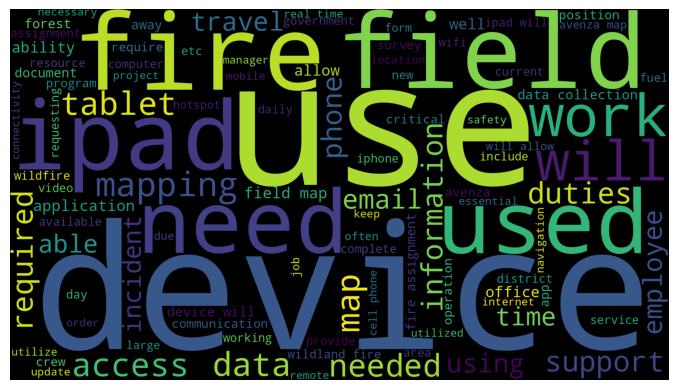

Generative Summary : JustificationMultipleDevice


  0%|          | 0/1568 [00:00<?, ?it/s]

Word Cloud : JustificationMultipleDevice


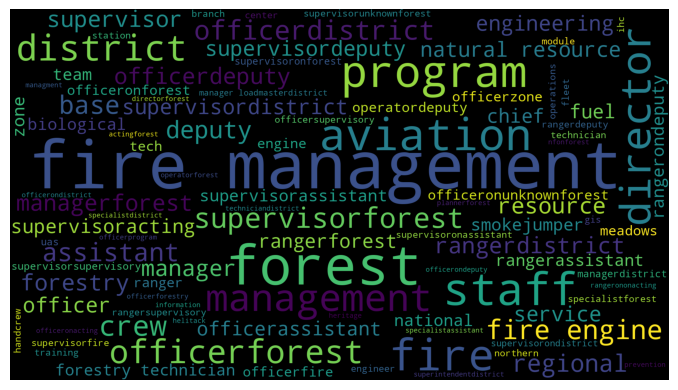

[2024-11-19 14:56:21 UTC]    INFO: Exiting __main__ model_wordclouds 
[2024-11-19 14:56:21 UTC]    INFO: Entering __main__ model_summary 
Generative Summary : JustificationNonStandard


  0%|          | 0/1568 [00:00<?, ?it/s]

This is a lot of information! It looks like you've gathered a collection of requests for iPads, iPhones, and mobile hotspots from Forest Service employees. You're likely trying to figure out what devices are needed, which requests are valid, and how to justify those requests. 

Here's a breakdown of the common justifications and some considerations for evaluation:

**Common Justifications:**

* **Field Work & Mapping:** This is by far the most common reason. Employees need devices for:
    * **Navigation:**  Using Avenza, Field Maps, and other apps to locate trails, fire perimeters, and project areas.
    * **Data Collection:** Recording data, taking photos, marking points of interest, and capturing GPS coordinates.
    * **Communication:** Accessing emails, incident reports, and collaborating on projects.
    * **Incident Management:** Sharing maps, briefing crews, and managing resources.
* **Travel & Remote Work:** 
    * **Email Access:**  Staying connected to agency emails, even wh

  0%|          | 0/1568 [00:00<?, ?it/s]

## Analysis of Mobile Device Exception Requests

This analysis examines exception requests for non-standard mobile device use within a forestry organization. 

**Common Justifications:**

* **Operational Needs:** Many requests cite the need for specific apps or functionality not available on standard devices, particularly related to fire management, data collection, and communication. 
* **Improved Productivity:**  Users often argue that their preferred device will enhance efficiency and effectiveness in performing their duties. 
* **Personal Preference:**  Some requests emphasize a preference for a particular device due to familiarity or user experience.

**Frequency of Requests:**

* **Fire Management:** The majority of requests originate from personnel involved in fire management, including fire management officers, helitack crews, and aviation staff. 
* **District Rangers:** A significant number of requests come from district rangers, indicating a need for flexibility in device use

  0%|          | 0/1568 [00:00<?, ?it/s]

Generative Sentiment Assignment : JustificationMultipleDevice


  0%|          | 0/1568 [00:00<?, ?it/s]

[2024-11-19 16:08:46 UTC]   DEBUG: ...saved and reloaded /home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/working_data/PHNEXP/PHNEXP-0-4-0/PHNEXP-0-4-0_output.bin 
[2024-11-19 16:08:46 UTC]   DEBUG: Saving the data to a file (/home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/working_data/PHNEXP/PHNEXP-0-4-0/PHNEXP-0-4-0_output.csv). 
[2024-11-19 16:08:46 UTC]   DEBUG: Saving the data to a file (/home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/working_data/PHNEXP/PHNEXP-0-4-0/PHNEXP-0-4-0_output.xlsx). 
[2024-11-19 16:08:47 UTC]    INFO: Entering __main__ get_metrics 
Total Records : 1568

Total Valid Records : 1405 (89.66%) 
Total Invalid Records : 162 (10.34%)
Total Valid Records : 1567

Vendor Distribution :
Vendor
verizon                                                            762
                                                                   320
n/a                                                                 35
at&t                              

In [ ]:
if __name__ == "__main__":

    set_library_configuration()
    start_t=perf_counter()
    print("BEGIN PROGRAM")

    ############################################
    # SECRETS & ENV VARIABLES
    ############################################
    load_dotenv()

    ############################################
    # GLOBAL CONFIGURATION
    ############################################
    #used for values outside standard ASCII, just do it, you'll need it
    ENCODING  ="utf-8"
    os.environ['PYTHONIOENCODING']=ENCODING
    #spacy requirement
    os.environ['TOKENIZERS_PARALLELISM']="false"

    debug.msg_info("Variable declaration.")    
    ############################################
    # GLOBAL VARIABLES
    ############################################
    DEBUG = 1
    DEBUG_DATA = 0
    
    # CODE CONSTRAINTS
    VERSION_NAME    = "PHNEXP"
    VERSION_MAJOR   = 0
    VERSION_MINOR   = 4
    VERSION_RELEASE = 0
    
    #used for values outside standard ASCII, just do it, you'll need it
    ENCODING  ="utf-8"
    TEXT_WIDTH=77
    BOLD_START = "\033[1m"
    BOLD_END = "\033[0;0m"
    
    ###########################################
    #- API Parameters for things like WordCloud
    ###########################################
    IMG_BACKGROUND=None                        #None without quotes or "black", "white", etc...
    IMG_FONT_SIZE_MIN=14
    IMG_WIDTH=1920
    IMG_HEIGHT=1080
    MAX_WORDS_IN_CLOUD=100    
    
    ############################################
    # APPLICATION VARIABLES
    ############################################
    PROJECT_ID= "usfs-gcp-rand-test-3"
    BUCKET_ID = "usfs-gcp-rand-test3-data-usc1"
    LOCATION = "us-central1"
    SPELL_CHECK_DISTANCE=2
    MINIMUM_AI_WAIT=1                         #seconds
    os.environ["MINIMUM_AI_WAIT"] = "str(MINIMUM_AI_WAIT)"    
    DATA_DIR = f"/home/jupyter/projects/data/{BUCKET_ID}/source_data/nlp/{VERSION_NAME}"
    OUTPUT_DIR=f"/home/jupyter/projects/data/{BUCKET_ID}/working_data/{VERSION_NAME}"
    
    EXCEL_CHAR_BOUNDARY=90
    DELIM="^"
    
    ############################################
    # GENERATIVE MODEL PARAMETERS
    ############################################
    the_model="unknown"
    model_temperature=0.0
    model_max_tokens=0
    model_max_token_response=0
    model_top_p=0.0
    model_frequency_penalty=0
    model_presence_penalty=0
    summary_token_max=0
    if environments[user_input]=="GCP":
        #model parameters
            #Gemini 1.5 Flash	google/gemini-1.5-flash-001 
            #Gemini 1.5 Prov	google/gemini-1.5-pro-001
            #                   google/gemini-1.5-pro
            #Gemini 1.0 Prov	google/gemini-1.0-pro-002
            #                   google/gemini-1.0-pro-001
            #                   google/gemini-1.0-pro
        #the_model="gemini-1.5-pro-001"
        the_model="gemini-1.5-flash"
        model_temperature=1.0
        model_max_tokens=8000
        model_max_token_response=8000
        model_top_p=0.95
        model_frequency_penalty=0
        model_presence_penalty=0
        summary_token_max=150
    else:
        #model parameters
        the_model="gpt-35-turbo-16k"
        model_temperature=1.0
        model_max_tokens=8000
        model_max_token_response=2000
        model_top_p=0.95
        model_frequency_penalty=0
        model_presence_penalty=0
        summary_token_max=150
    ############################################
    # PROMPT PARAMETERS
    ############################################
    PROMPT_SUMMARY_LIMIT="500"                   #number of words to generate
    PROMPT_SUMMARY_METHOD=" abstractive "        #abstractive or extractive
    PROMPT_INJECTION_MODELS=[
                             #https://python.langchain.com/v0.1/docs/guides/productionization/safety/hugging_face_prompt_injection/
                             #from optimum.onnxruntime import ORTModelForSequenceClassification
                             "protectai/deberta-v3-base-prompt-injection-v2",
                            ]
    response_categories = "Data Management, Workplace Concerns, Public Trust, Ethical Concerns, Resources, Knowledge"
    
    JSON_PAYLOAD = '{ \
      "Sentiment": 0.0 \
      "SentimentConfidence": 0.0, \
      "Category": "Some Category", \
    }'
    
    JSON_ERROR = ' { \
        "Sentiment": 100, \
        "SentimentConfidence": 100, \
        "Category": "error", \
    }'
    
    EXAMPLE_JSON = '{ \
      "Sentiment": -0.5, \
      "SentimentConfidence": 0.8, \
      "Category": "Data Management", \
    }'
    
    ########################################
    #Define Potential "answers" from the various neural layers
    #Is the Prompt Detected?
    ########################################
    id2label = {
        'LEGIT':    False,
        'POSITIVE': False,
        'LABEL_1':  False,
        'SAFE':     False,
        
        'INJECTION':True,
        'NEGATIVE': True,
        'LABEL_0':  True,
        'UNSAFE':   True,
    }
    prompt_defense_model_chunk_size=512

    ########################################
    #Safety filter settings for Google GenAI
    ########################################
    safety_settings = [
      {
        "category": "HARM_CATEGORY_HARASSMENT",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
      {
        "category": "HARM_CATEGORY_HATE_SPEECH",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
      {
        "category": "HARM_CATEGORY_SEXUALLY_EXPLICIT",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
      {
        "category": "HARM_CATEGORY_DANGEROUS_CONTENT",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
    ]    
    
    
    ############################################
    # PDF mapping
    ############################################
    DATETIME_FORMAT="%m/%d/%y"
    UNKNOWN="Unknown"
    NODATA="No Data"
    
    SUPNAME_FIELD="Click here to enter text_11".lower()
    SUPDATE_FIELD="Date5_af_date".lower()
    SUPNONSTD_FIELD="NonStandard Device".lower()
    SUPMLTIPLE_FIELD="Exception to One Device".lower()
    SUPBOTH_FIELD="Both".lower()
    SUPTITLE_FIELD="SupervisorTitle".lower()
    SUPRMRK_FIELD="Click here to enter text_12".lower()
   
    BOSSNAME_FIELD="Click here to enter text_13".lower()
    BOSSDATE_FIELD="Date6_af_date".lower()
    BOSSNONSTD_FIELD="NonStandard Device_2".lower()
    BOSSMLTPLE_FIELD="Exception to One Device_2".lower()
    BOSSBOTH_FIELD="Both_2".lower()
    BOSSTITLE_FIELD="SeniorLevelTitle".lower()
    BOSSRMRK_FIELD="Click here to enter text_14".lower()

    #CIONAME_FIELD="Click here to enter text_15".lower()
    CIONAME_FIELD="text_15".lower()
    CIODATE_FIELD="Date7_af_date".lower()
    #CIONONSTD_FIELD="NonStandard Device_3".lower()
    CIONONSTD_FIELD="Device_3".lower()    
    #CIOMLTIPLE_FIELD="Exception to One Device_3".lower()
    CIOMLTIPLE_FIELD="Device_3".lower()    
    CIOBOTH_FIELD="Both_3".lower()
    #CIORMRK_FIELD="Click here to enter text_16".lower()
    CIORMRK_FIELD="text_16".lower()    
   
    USERNAME_FIELD="Click here to enter text".lower()
    USEREMAIL_FIELD="Click here to enter text_2".lower()
    USERTITLE_FIELD="Click here to enter text_3".lower()
    USERORG_FIELD="Click here to enter text_4".lower()
    USERADDR_FIELD="Click here to enter text_5".lower()
    USEREQUIP_FIELD="Click here to enter text_6".lower()
    USERPHNREQ_FIELD="Click here to enter text_7".lower()
    USERDEVREQ_FIELD="Click here to enter text_8".lower()
    USERVENDOR_FIELD="Click here to enter text_9".lower()
    USERSHIP_FIELD="Click here to enter text_10".lower()
    USERDATE_FIELD="Date7_af_date".lower()
    USERNONSTD_FIELD="JUSTIFICATION FOR NONSTANDARD DEVICE".lower()
    USERMLTIPLE_FIELD1="JUSTIFICATION FOR EXCEPTION TO ONE DEVICE DIRECTIVE".lower()
    USERMLTIPLE_FIELD2="JUSTIFICATION FOR MULTIPLE DEVICES".lower()

    MULTIDEV_FIELD="EXCEPTION FOR MULTIPLE DEVICES".lower()
    NONSTDDEV_FIELD="EXCEPTION FOR NONSTANDARD DEVICE".lower()

    #money_regex  =  re.compile(r'\$(?:(?:[1-9][0-9]{0,2}(?:,[0-9]{3})*|0)(?:.[0-9]{2})?)')
    #money_regex  =  re.compile(r'\$(?:(?:[1-9][0-9]{0,2}(?:,[0-9]{3})*|0)(?:.[0-9]{2})?)')    
    #money_regex  =  re.compile(r'\$(?:(?:[1-9][0-9]{0,2}(?:,[0-9]{3})*|0)(?:.\d{2})?)')        
    #money_regex = re.compile(r"\d{1,3}(?:,\d{3})*\.\d{2}")
    #money_regex = re.compile(r"\d{1,4}(?:,\d{4})*\.\d{2}")
    money_regex = re.compile(r"\d{1,4}(?:,\d{4})*\.\d{2}")
    
    #https://stackoverflow.com/questions/3868753/find-usa-phone-numbers-in-python-script
    phone_regex = re.compile(r"\d{3}[-\.\s]??\d{3}[-\.\s]??\d{4}|\(\d{3}\)\s*\d{3}[-\.\s]??\d{4}|\d{3}[-\.\s]??\d{4}")
    ############################################
    # NLTK instantiation
    ############################################
    debug.msg_debug(f"...StopWords instantiated.")
    stop_words = set(stopwords.words("english"))
    debug.msg_debug(f"...PortStemmer instantiated.")
    stemmer = PorterStemmer()
    debug.msg_debug(f"...Lemmatizer instantiated.")
    lemmatizer = WordNetLemmatizer()
    
    #setup the text wrapper
    debug.msg_debug(f"...Text Wrapper instantiated.")
    wrapper = textwrap.TextWrapper(width=TEXT_WIDTH)
    
    #show your libraries
    lib_diagnostics()

    ###########################################
    #- OPENAI
    # Generative AI Library Configuration
    # Tailored for OpenAI environment on Azure for now.  API keys and other relevant information in .bashrc_keys environment variable on system for security.
    ###########################################
    if environments[user_input]=="GCP":
        debug.msg_info("GCP GenAI setup")
        client=setup_gcpgenai_client()
    else:
        debug.msg_info("OPENAI setup")
        client=setup_openai_client()
    

    stop = set(stopwords.words('english'))
    exclude = set(string.punctuation)
    lemma = WordNetLemmatizer()
    whiteSpaceRegex = "\\s";
    def clean(doc):
        stop_free = " ".join([i for i in doc.lower().split() if i not in stop])
        punc_free = "".join(ch for ch in stop_free if ch not in exclude)
        normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
        return normalized

    ###########################################
    #- Workhorse routine
    ###########################################
    #process_pdfs()
    df=process_exemptions(process_pdfs())

    ##########################################################
    # Save results - intermediate step
    ##########################################################        
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    save_filename=f"{data_version_release}"
    output_data(save_filename, df)
    
    model_topics(df)
    model_wordclouds(df)
    model_summary(df)
    
    df=model_sentiment(df)
    
    ##########################################################
    # Save results - final save
    ##########################################################        
    #establish data version, aligned with code
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])
    save_filename=f"{data_version_release}"
    output_data(save_filename, df)
    
    
    get_metrics(df)
    
    end_t=perf_counter()
    print("END PROGRAM")
    print(f"Elapsed time: {end_t - start_t}")
